In [1]:
# for development
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, load_digits

from shapediscover import ShapeDiscover, shapediscover_plot

from synthetic_data import sphere, interval, double_circle
from plotting_and_preprocessing import plot_and_return_2d_embedding, plot_mapper, plot_ball_mapper

/Users/luisscoccola/code/shapediscover/venv_main/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Simple shapes

----- Interval -----
pointcloud shape: (1000, 2)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


time create graph 6.490881681442261
time clustering 0.06715083122253418
time optimization 1.360032081604004
time create simplicial complex 0.27597880363464355
time compute persistence 0.0002276897430419922
initialization precover


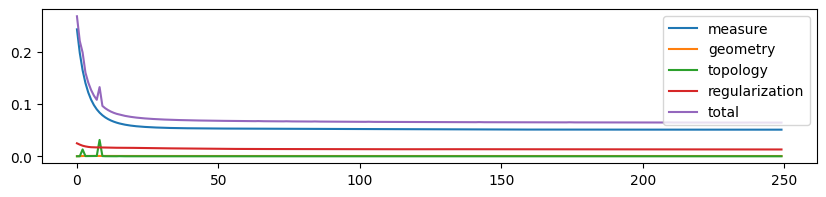

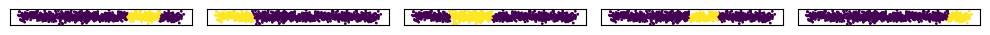

output precover


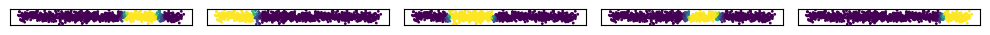

output fuzzy cover


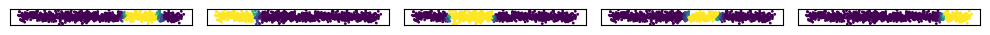

output cover


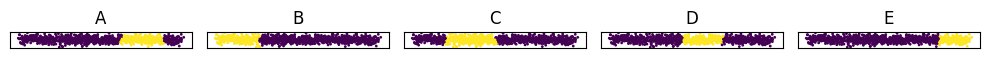

nerve of fuzzy cover by thresholding at 0.1


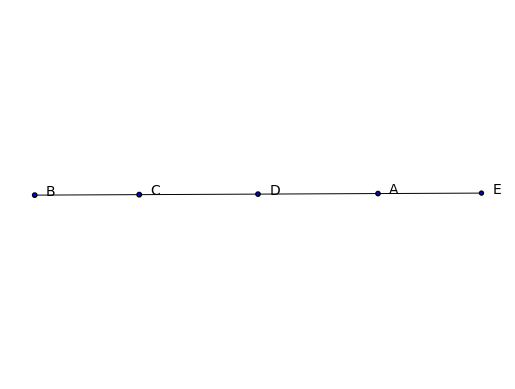

barcode of fuzzy cover


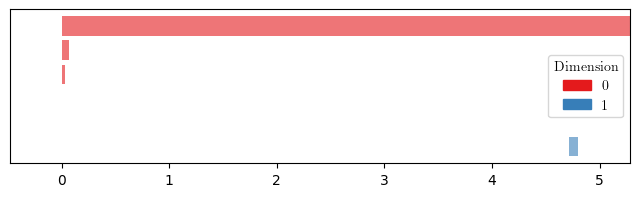

----- Blobs -----
pointcloud shape: (500, 2)
time create graph 0.07011294364929199
time clustering 0.008471965789794922
time optimization 0.4730491638183594
time create simplicial complex 0.21850013732910156
time compute persistence 0.0002579689025878906
initialization precover


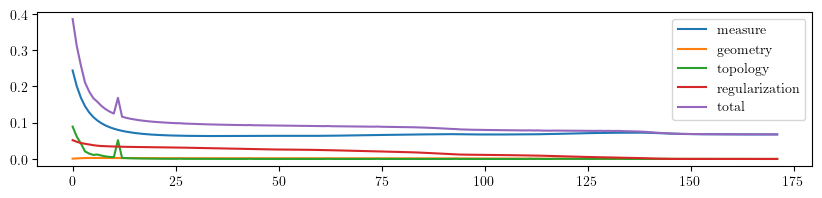

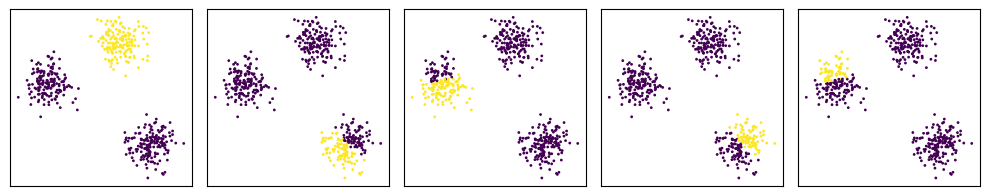

output precover


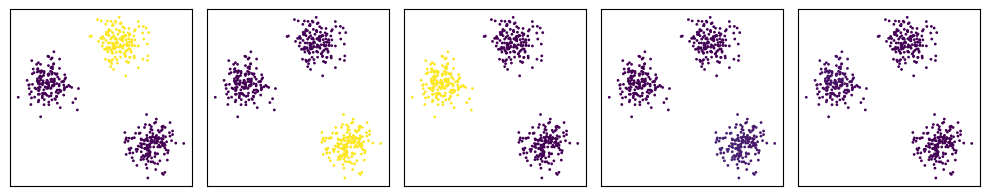

output fuzzy cover


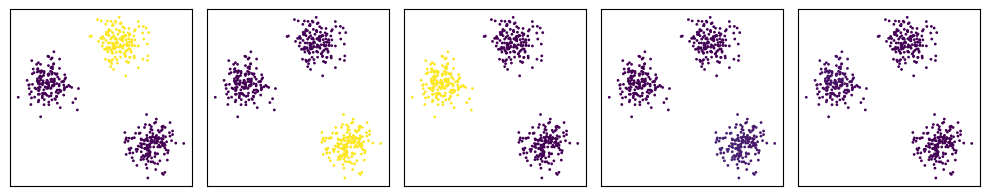

output cover


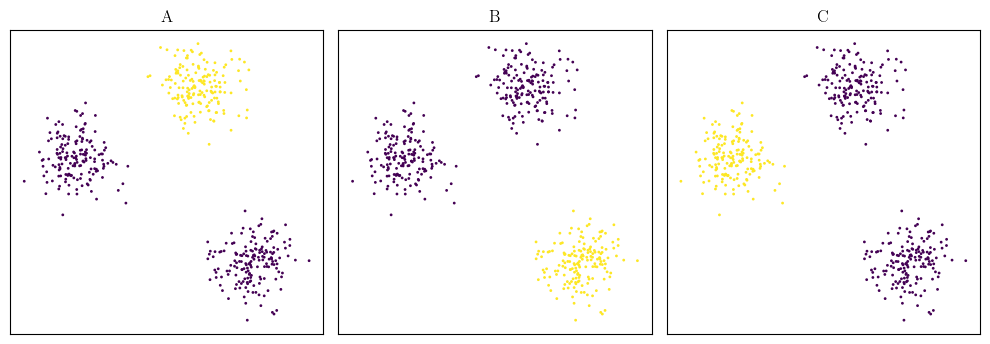

nerve of fuzzy cover by thresholding at 0.1


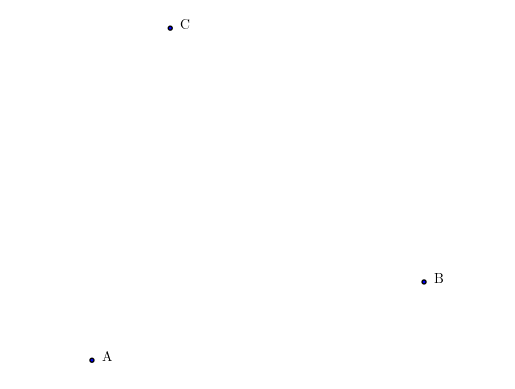

barcode of fuzzy cover


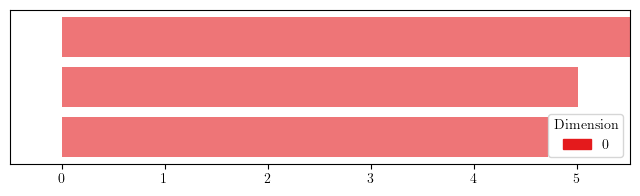

----- Circle -----
pointcloud shape: (1000, 2)
time create graph 0.08043885231018066
time clustering 0.029703855514526367
time optimization 0.646169900894165
time create simplicial complex 0.43512606620788574
time compute persistence 0.0002300739288330078
initialization precover


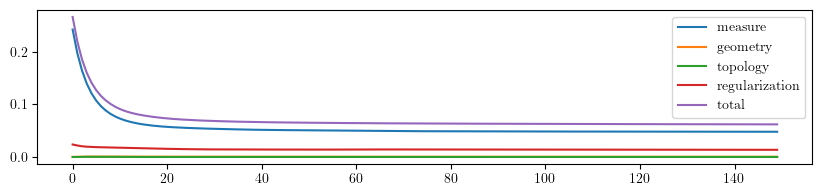

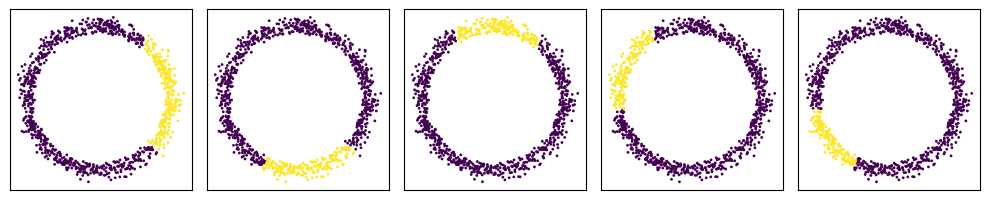

output precover


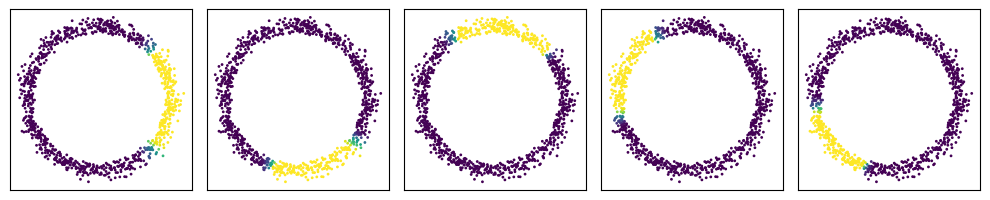

output fuzzy cover


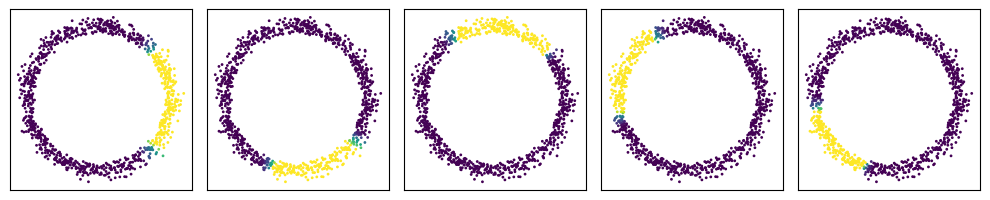

output cover


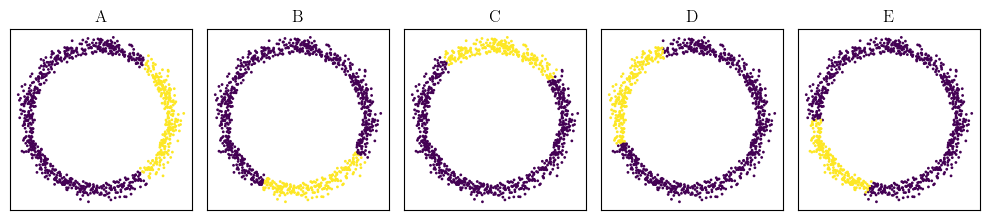

nerve of fuzzy cover by thresholding at 0.1


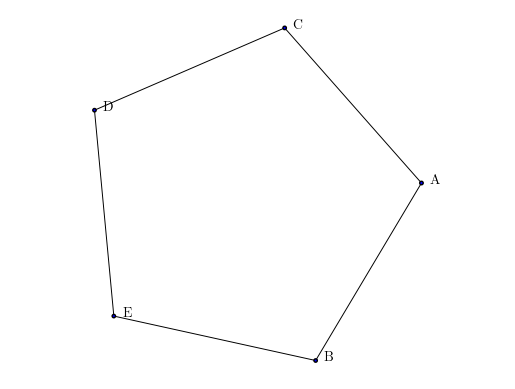

barcode of fuzzy cover


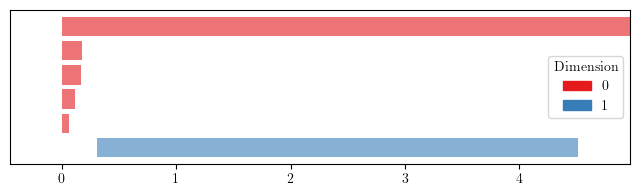

----- Two circles -----
pointcloud shape: (1000, 2)
time create graph 0.07471489906311035
time clustering 0.03229022026062012
time optimization 0.5181441307067871
time create simplicial complex 0.21241283416748047
time compute persistence 0.0001010894775390625
initialization precover


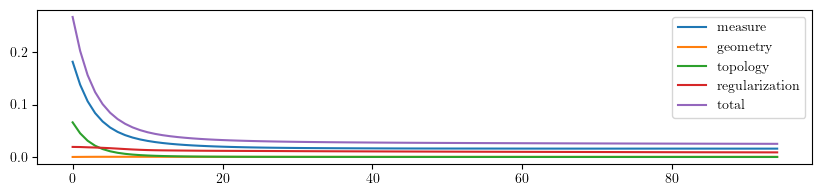

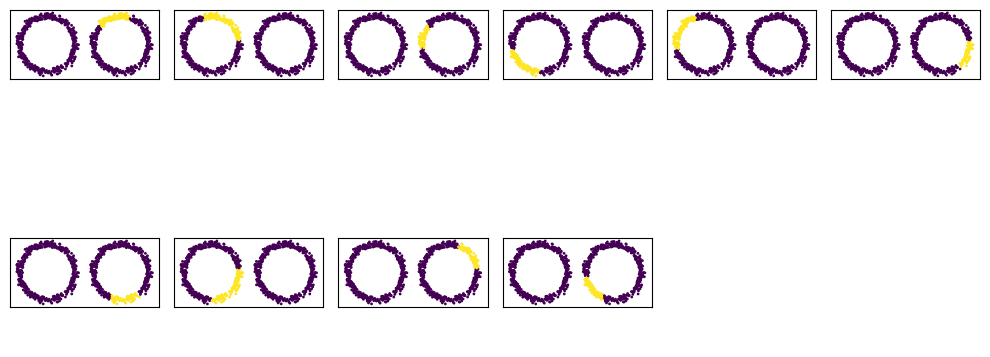

output precover


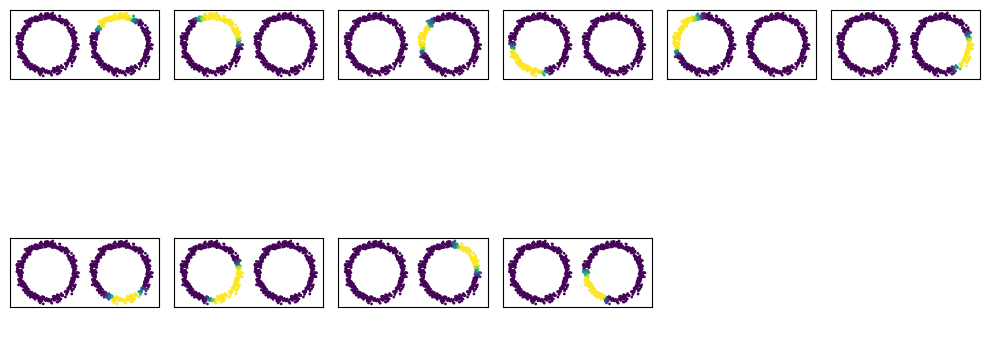

output fuzzy cover


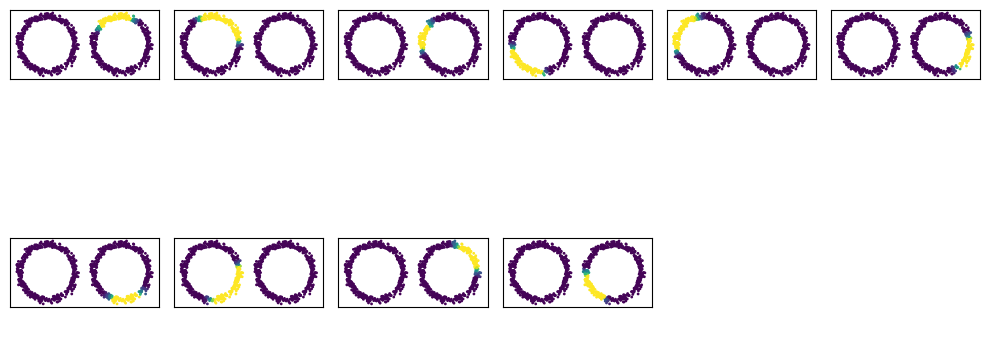

output cover


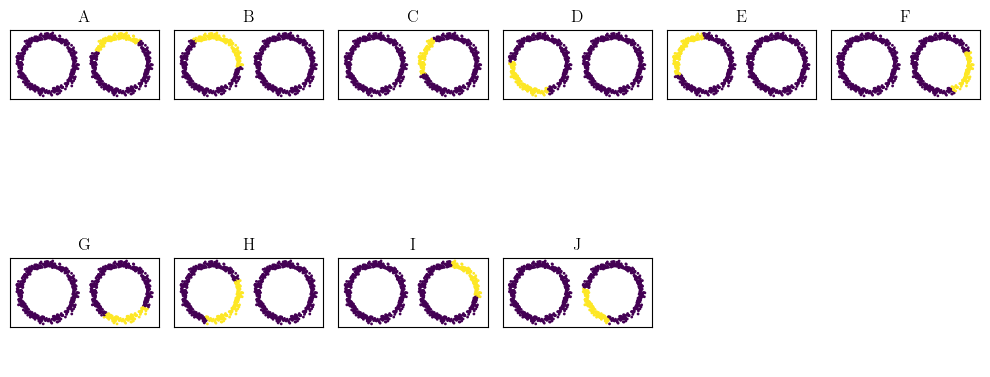

nerve of fuzzy cover by thresholding at 0.1


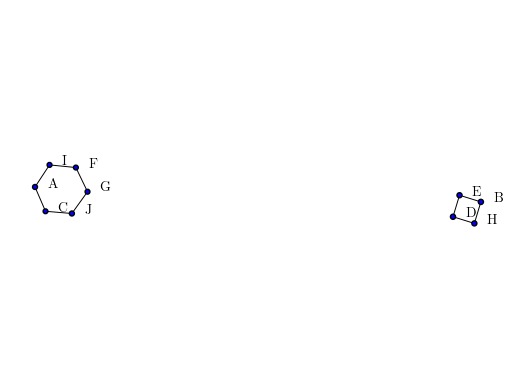

barcode of fuzzy cover


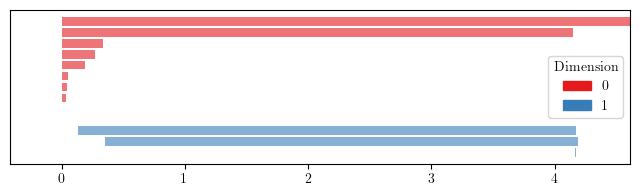

In [3]:
datasets = [
    interval(1000, noise_variance=0.001),
    make_blobs(n_samples=500, centers=3, n_features=2, random_state=0, cluster_std=0.4)[0],
    sphere(1000, 1, noise_variance=0.01),
    double_circle(500, noise_variance=1e-2),
]
names = ["Interval", "Blobs", "Circle", "Two circles"]
n_covers = [5, 5, 5, 10]

for X, name, n_cov in zip(datasets, names, n_covers):
    print("----- " + name + " -----")
    discover = ShapeDiscover(
        n_cover=n_cov,
    )
    discover.fit(X)
    discover.fit_persistence()
    shapediscover_plot(discover, X, cover_threshold=0.1, max_vertex_size=0.01)

# Topological inference

## Sphere

In [ ]:
X = sphere(2000, 2)
discover = ShapeDiscover(
    n_cover=5,
    loss_weights=[1,10,1,10],
    n_max_iter=500,
)
discover.fit(X)
discover.fit_persistence(max_dimension=2, verbose=True)
shapediscover_plot(discover, X, cover_threshold=0.3)

NameError: name 'sphere' is not defined

## Human

pointcloud shape: (9508, 3)
time create graph 0.2409520149230957
time clustering 0.32047295570373535
time optimization 2.9540627002716064


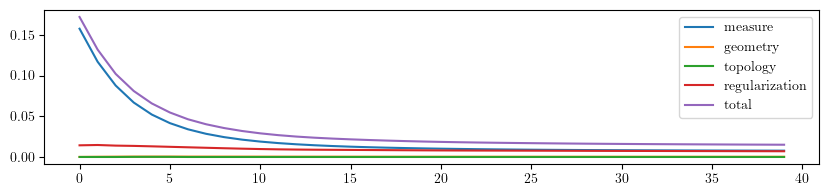

In [6]:
X = np.loadtxt("datasets/human.txt")
discover = ShapeDiscover(
    n_cover=17,
)
discover.fit(X)

nerve of fuzzy cover by thresholding at 0.5


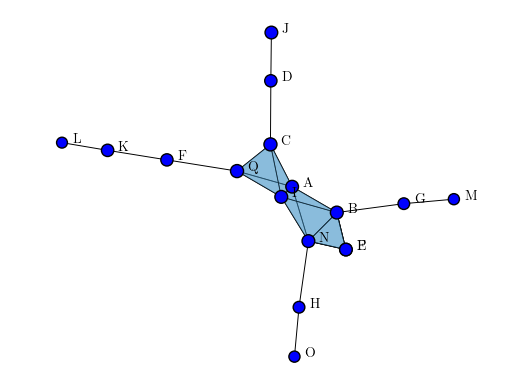

In [8]:
shapediscover_plot(
    discover,
    X,
    max_vertex_size=0.03,
    plot_subfunctions=["nerve"],
)

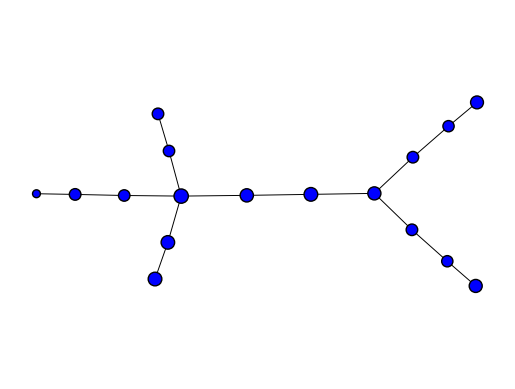

In [9]:
# mapper
overlap_perc = 0.2
dbscan_eps = 0.1
n_intervals = 9

filtering_function = X[:, 1]

mapper_cover = plot_mapper(
    X,
    filtering_function,
    overlap_perc,
    n_intervals,
    dbscan_eps,
    X,
    max_vertex_size=0.03,
    plot_subfunctions=["nerve"],
)

cover size: 18


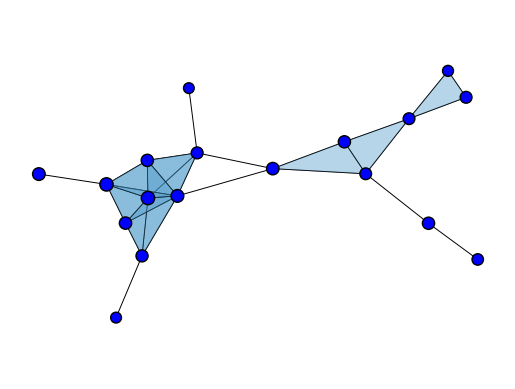

cover size: 26


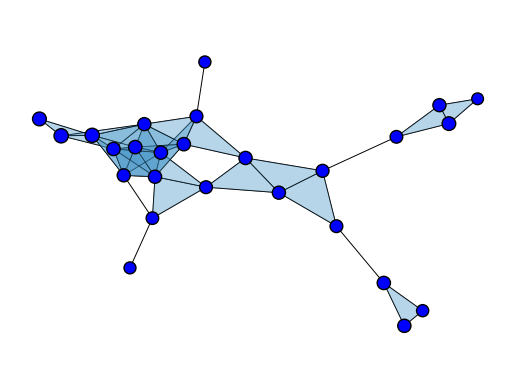

cover size: 48


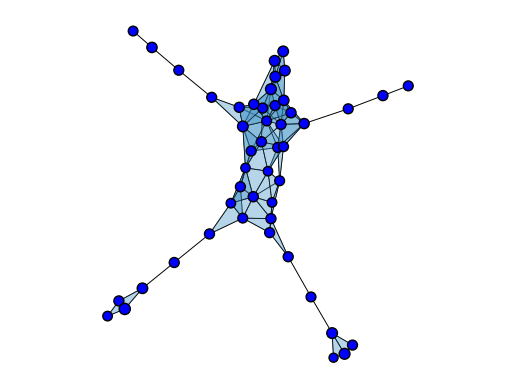

In [10]:
# BallMapper
for eps,eps_str in zip([0.25,0.2, 0.15], ["025","02","015"]):
    _, indices = plot_ball_mapper(
        X,
        eps,
        X,
        max_vertex_size=0.03,
        plot_letters=False,
        plot_subfunctions=["nerve"],
    )

## Octopus

pointcloud shape: (7812, 3)
time create graph 0.196746826171875
time clustering 0.3981766700744629
time optimization 2.3894529342651367


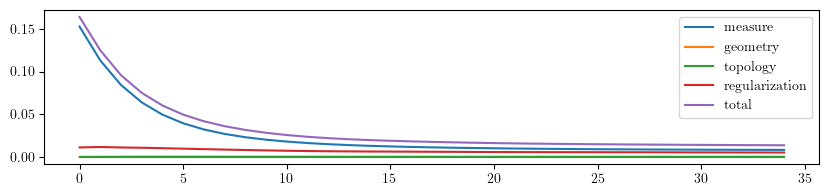

In [11]:
X = np.loadtxt("datasets/octopus.txt")
discover = ShapeDiscover(
    n_cover=20,
)
discover.fit(X)

nerve of fuzzy cover by thresholding at 0.5


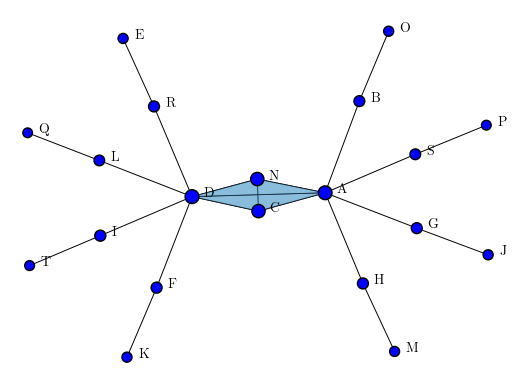

In [12]:
shapediscover_plot(
    discover,
    X[:, [1, 2]],
    max_vertex_size=0.03,
    plot_subfunctions=["nerve"],
)

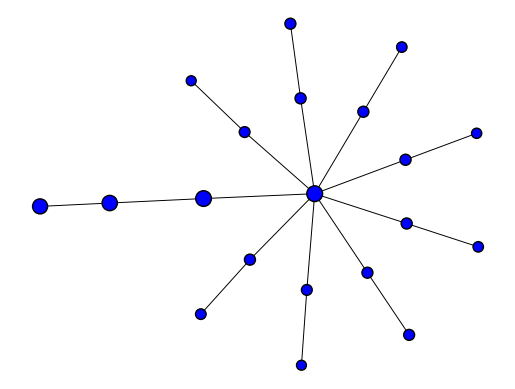

In [13]:
# mapper
overlap_perc = 0.1
dbscan_eps = 0.1
n_intervals = 6

filtering_function = X[:, 2]

mapper_cover = plot_mapper(
    X,
    filtering_function,
    overlap_perc,
    n_intervals,
    dbscan_eps,
    X[:,[1,2]],
    max_vertex_size=0.03,
    plot_subfunctions=["nerve"],
)

cover size: 51


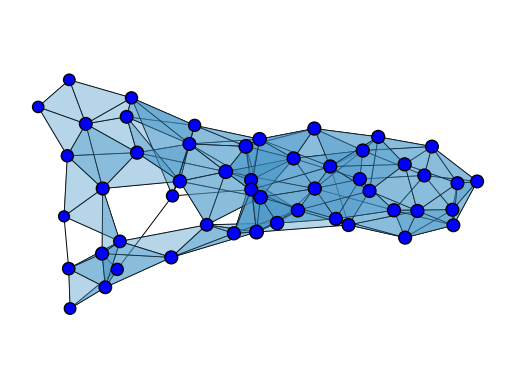

cover size: 68


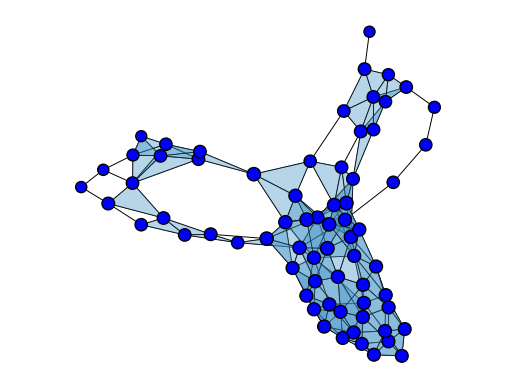

cover size: 80


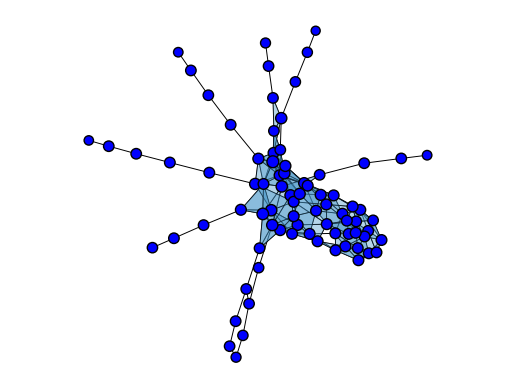

In [15]:
# BallMapper
for eps,eps_str in zip([0.2, 0.175, 0.15], ["02","0175","015"]):
    _, indices = plot_ball_mapper(
        X,
        eps,
        X,
        max_vertex_size=0.03,
        plot_letters=False,
        plot_subfunctions=["nerve"],
    )

## Rat brain torus

pointcloud shape: (10000, 6)
time create graph 0.288283109664917
time clustering 0.21450591087341309
time optimization 4.085970878601074


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


time create simplicial complex 1.41575288772583
time compute persistence 0.0007231235504150391
barcode of fuzzy cover


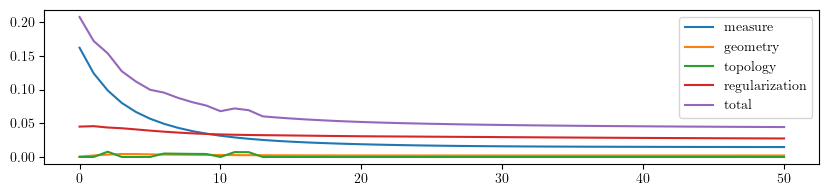

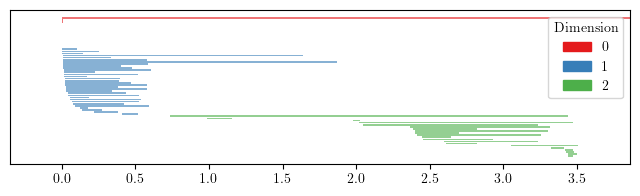

In [18]:
X = np.load("datasets/rat_brain/toremb_Y.npy")
discover = ShapeDiscover(
    n_cover=15,
)
discover.fit(X)
discover.fit_persistence(max_dimension=2)
shapediscover_plot(discover, None, plot_subfunctions=["barcode"], plot_name="shapediscover_ratbrain")

In [19]:
from experiment_functions import correct_homology_quotient
correct_homology_quotient(discover.persistence_diagram_, [1,2,1])

0.208

## Dynamical system video

pointcloud shape: (2022, 10)
time create graph 0.10166192054748535
time clustering 0.1005699634552002
time optimization 2.011737823486328
time create simplicial complex 35.24614405632019
time compute persistence 0.09015774726867676
barcode of fuzzy cover


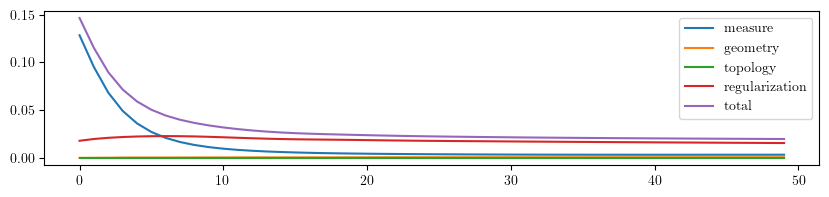

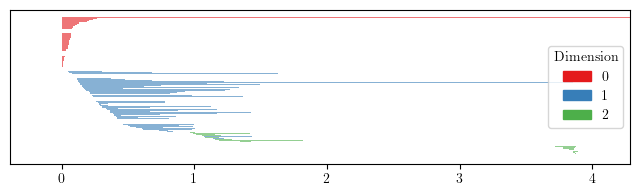

In [20]:
X = np.load("datasets/dynamical_system_video.npy")
discover = ShapeDiscover(
    n_cover=52,
)
discover.fit(X)
discover.fit_persistence(max_dimension=2)
shapediscover_plot(discover, None, plot_subfunctions=["barcode"])

# Large scale visualization

## Digits data

/Users/luisscoccola/code/shapediscover/venv_main/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/luisscoccola/code/shapediscover/venv_main/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


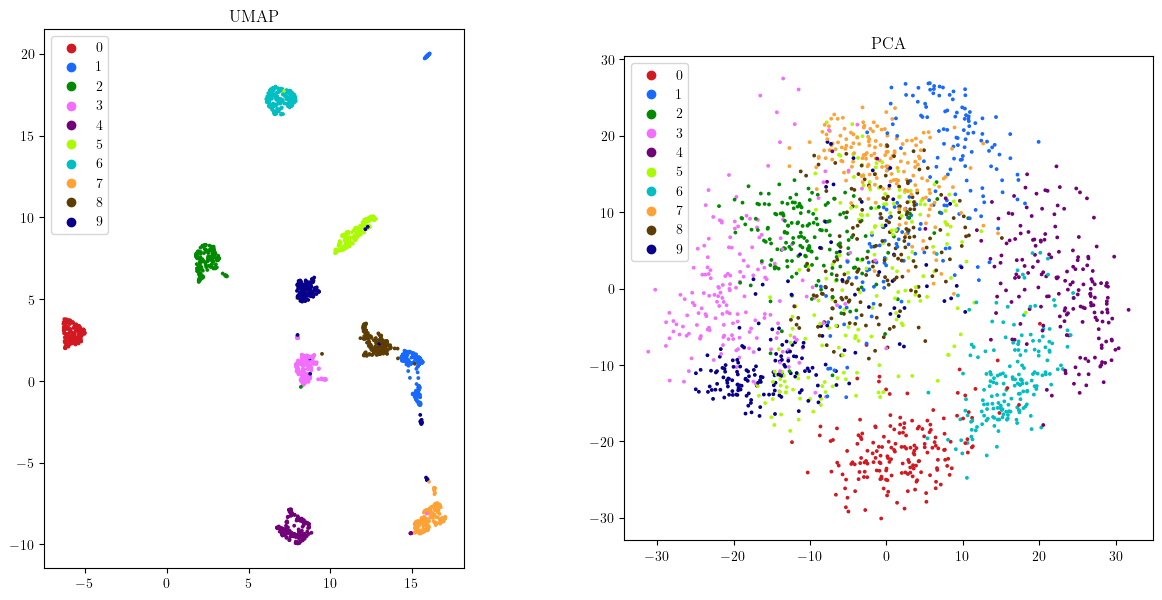

In [23]:
X, y = load_digits(return_X_y=True)
X_umap, X_pca = plot_and_return_2d_embedding(X,y=y, point_size=3)

pointcloud shape: (1797, 64)
time create graph 0.10576701164245605
time clustering 0.03208303451538086
time optimization 2.2816162109375


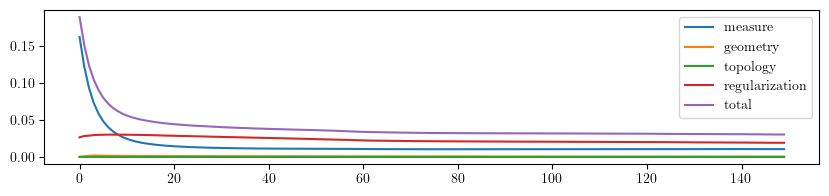

In [24]:
discover = ShapeDiscover(
    n_cover=15,
)
discover.fit(X)

output cover


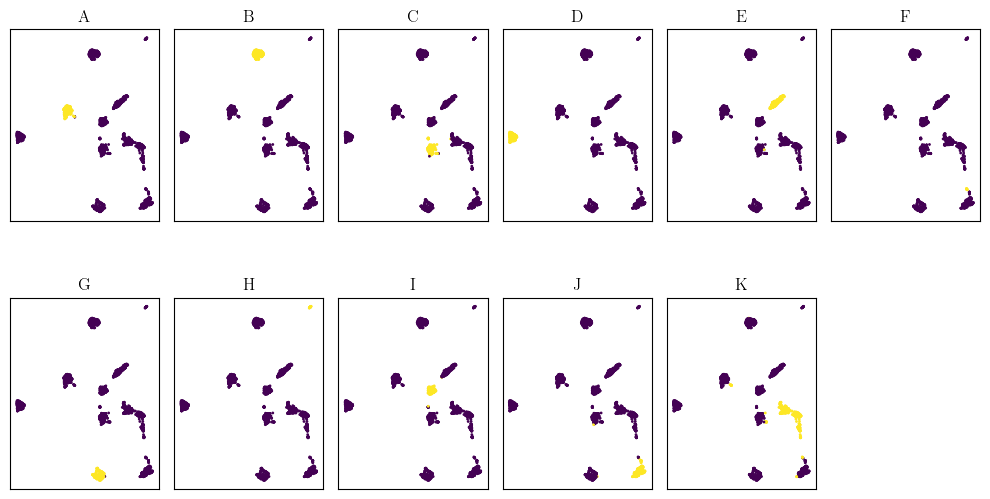

visualizations/pyvis_test.html
nerve of fuzzy cover by thresholding at 0.5


In [25]:
shapediscover_plot(
    discover,
    X_umap,
    y=y,
    cover_threshold=0.5,
    max_vertex_size=10,
    interactive=True,
    plot_subfunctions=["nerve","cover"]
)

## C. Elegans

/Users/luisscoccola/code/shapediscover/venv_main/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/luisscoccola/code/shapediscover/venv_main/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


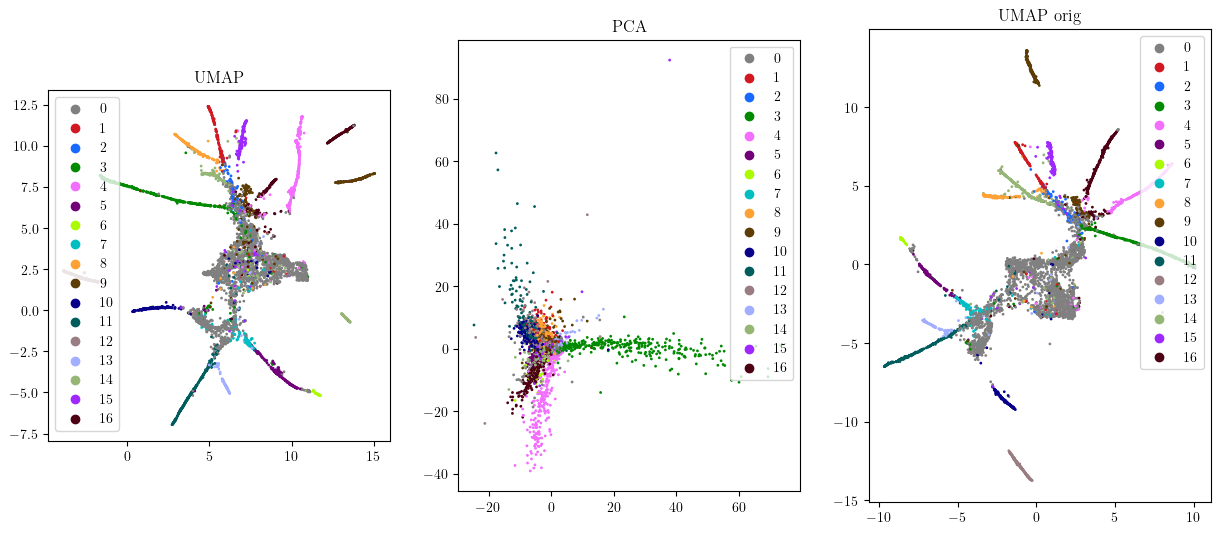

In [27]:
import csv

cell_data_dir = "datasets/celegans_embryo_data"

with open(f"{cell_data_dir}/CESub_Xa.csv", "r") as f:
    reader = csv.reader(f)
    data = list(reader)
data = data[1:]
data = [item[1:] for item in data]
X = np.array(data, dtype="float")

with open(f"{cell_data_dir}/CESub_Xu.csv", "r") as f:
    reader = csv.reader(f)
    data = list(reader)
data = data[1:]
data = [item[1:] for item in data]
X_umap = np.array(data, dtype="float")

with open(f"{cell_data_dir}/celltype.csv", "r") as f:
    reader = csv.reader(f)
    data = list(reader)
celltype = data[1:]
y = [item[1] for item in celltype]

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_numeric = label_encoder.fit_transform(y)
classes = label_encoder.classes_

keep = [0, 2, 1, 4, 5, 7, 8, 9, 11, 12, 14, 15, 17, 18, 19, 20]
y_filtered = [i if i in keep else -1 for i in y_numeric]

X_umap2, X_pca = plot_and_return_2d_embedding(
    X, y=y_filtered, X_dim_red=X_umap, X_dim_red_name="UMAP orig", n_neighbors=15, dummy_legend=True
)


pointcloud shape: (6188, 50)
time create graph 0.23735308647155762
time clustering 0.5272641181945801
time optimization 43.996089935302734


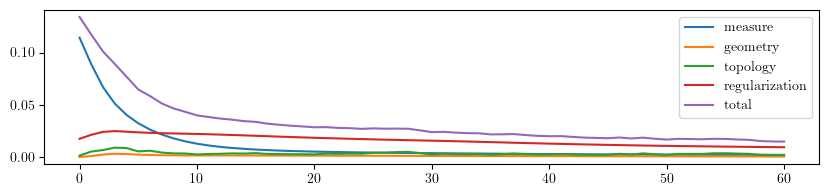

In [28]:
discover = ShapeDiscover(
    n_cover=100,
)
discover.fit(X)

output cover


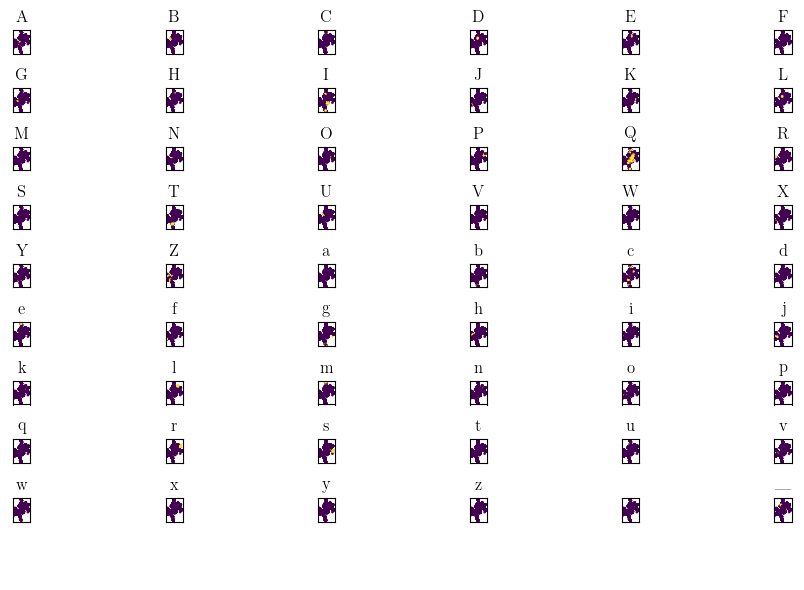

visualizations/pyvis_test.html
nerve of fuzzy cover by thresholding at 0.6


In [29]:
shapediscover_plot(
    discover,
    X_umap,
    y=y_filtered,
    cover_threshold=0.6,
    max_vertex_size=10,
    interactive=True,
    dummy_legend=True,
    plot_subfunctions=["nerve", "cover"]# "initialization_precover"]
)

## MNIST

100%|██████████| 9.91M/9.91M [00:00<00:00, 13.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 2.01MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.03MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.70MB/s]
/Users/luisscoccola/code/shapediscover/venv_main/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/luisscoccola/code/shapediscover/venv_main/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


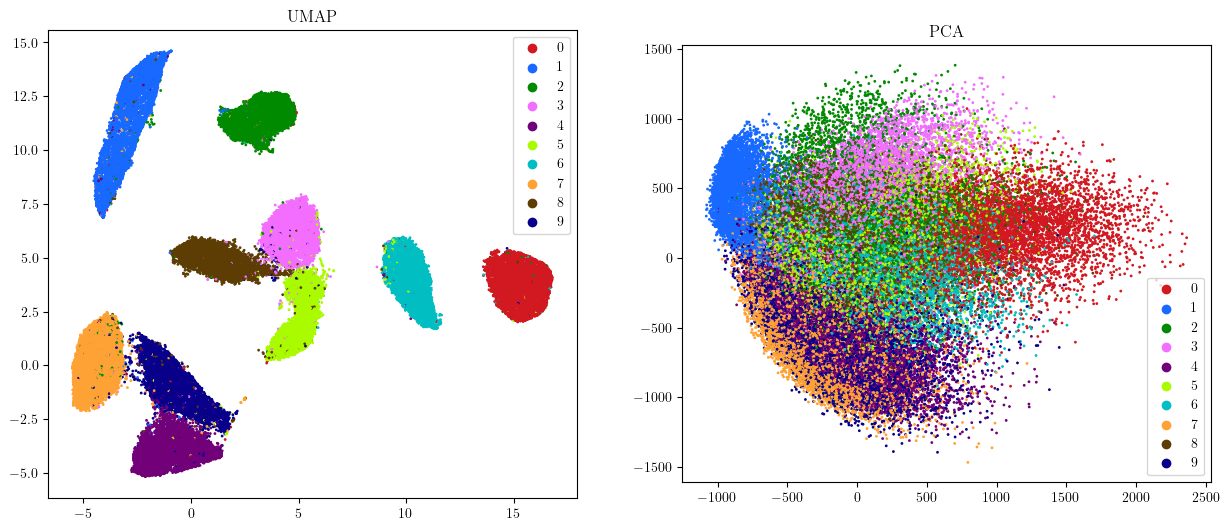

In [31]:
import torchvision

mnist_dataset = torchvision.datasets.MNIST(root="./datasets", download=True)
mnist_array = np.array(
    [np.array(image_label[0]).flatten() for image_label in mnist_dataset]
)
mnist_labels = np.array([image_label[1] for image_label in mnist_dataset])

X = mnist_array
y = mnist_labels

X_umap, X_pca = plot_and_return_2d_embedding(X, y=y)

pointcloud shape: (60000, 784)
time create graph 4.765177249908447
time clustering 2.924058198928833
time optimization 159.9628496170044


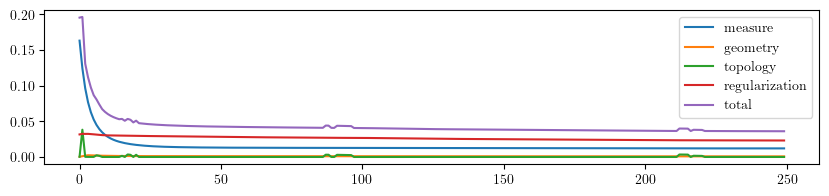

In [32]:
discover = ShapeDiscover(
    n_cover=15,
    loss_weights=[1,10,1,10],
    early_stop_tolerance=1e-5,
)
discover.fit(X)

output cover


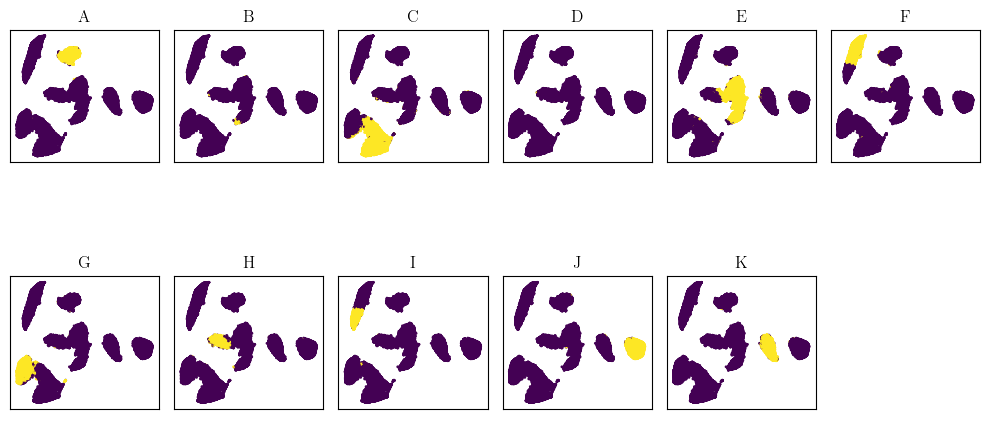

visualizations/pyvis_test.html
nerve of fuzzy cover by thresholding at 0.8


In [33]:
shapediscover_plot(
    discover,
    X_umap,
    y=y,
    cover_threshold=0.8,
    max_vertex_size=10,
    interactive=True,
    plot_subfunctions=["nerve", "cover"]
)